<a href="https://colab.research.google.com/github/Madhavi-1234/Machine-Learning-Practice/blob/main/End__to_End__toy_project_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import numpy as np
import pandas as pd


In [8]:
from google.colab import files

uploaded= files.upload()


Saving placement.csv to placement (1).csv


In [44]:
# dataframe
df= pd.read_csv('placement.csv')

In [45]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [46]:
# Shape of the dataset
df.shape

(100, 4)

# Here we will perform



1.  EDA + preprocessing

2.  input/ output column

3.  scale the values
4.   train/ test split
5.  model training
6.  model evalution/ model selection

In [47]:
## removing the unnecessary column

df.iloc[:,1:]

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0
...,...,...,...
95,4.3,200.0,0
96,4.4,42.0,0
97,6.7,182.0,1
98,6.3,103.0,1


In [48]:
# data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [49]:
# null value
df.isnull().sum().sum()

np.int64(0)

In [50]:
import matplotlib.pyplot as plt

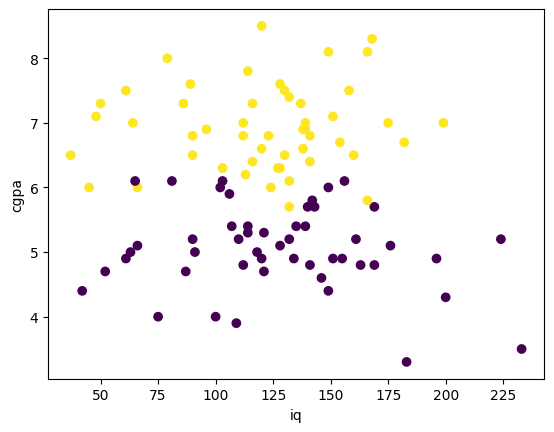

In [51]:
plt.scatter(df['iq'], df['cgpa'], c= df['placement'])
plt.xlabel('iq')
plt.ylabel('cgpa')
plt.show()

In [52]:
x= df.iloc[:,0:2]
y= df.iloc[:,-1]

In [53]:
x

,Unnamed: 0,cgpa
0,0,6.8
1,1,5.9
2,2,5.3
3,3,7.4
4,4,5.8
...,...,...
95,95,4.3
96,96,4.4
97,97,6.7
98,98,6.3


In [54]:
y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [55]:
from sklearn.model_selection import train_test_split

In [56]:
x_train, x_test, y_train, y_test=  train_test_split(x,y, test_size= 0.2, random_state= 42)


In [57]:
x_train

,Unnamed: 0,cgpa
55,55,7.8
88,88,4.4
26,26,7.0
42,42,7.6
69,69,8.5
...,...,...
60,60,6.9
71,71,6.1
14,14,6.1
92,92,5.2


In [58]:
y_train

,placement
55,1
88,0
26,1
42,1
69,1
...,...
60,1
71,1
14,0
92,0


In [59]:
### preprocessing

from sklearn.preprocessing import StandardScaler

scaler= StandardScaler()


In [60]:
x_train= scaler.fit_transform(x_train)

x_test= scaler.transform(x_test)

In [61]:
### model training

from sklearn.linear_model import LogisticRegression

clf= LogisticRegression()




In [62]:
clf.fit(x_train, y_train)

LogisticRegression()

In [63]:
## evaluation


y_pred= clf.predict(x_test)

In [64]:
y_pred

array([1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0])

In [65]:
from sklearn.metrics import accuracy_score, confusion_matrix

In [66]:
score= accuracy_score(y_test, y_pred)
score


0.9

In [68]:
metrix= confusion_matrix(y_test, y_pred)
metrix

array([[10,  0],
       [ 2,  8]])

<Axes: >

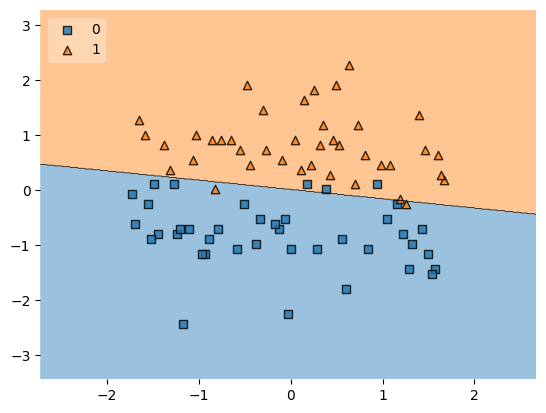

In [75]:
# for checking the decision boundary

from mlxtend.plotting import plot_decision_regions

plot_decision_regions(x_train, y_train.values, clf= clf, legend= 2)

In [77]:
import pickle
pickle.dump(clf, open('model.pkl', 'wb'))